In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
import math
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

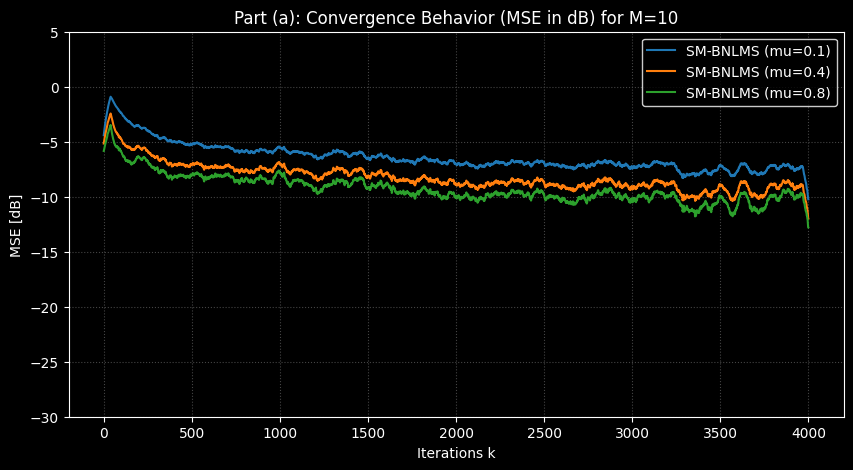

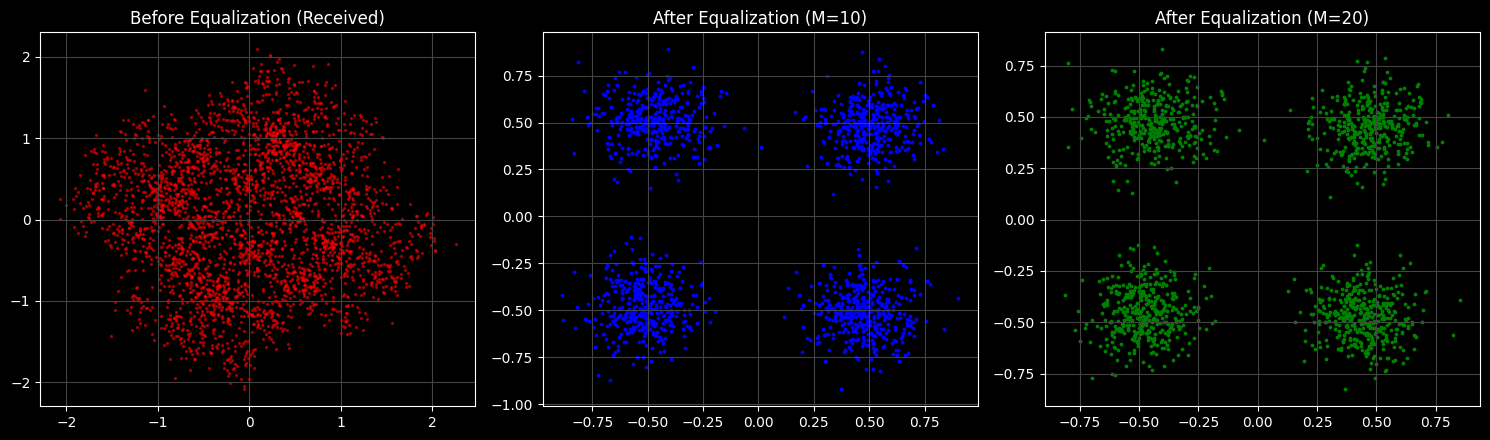

In [2]:
num_samples = 4000
# 4-QAM 發射基底
s = (np.random.choice([-1, 1], num_samples) + 1j * np.random.choice([-1, 1], num_samples)) / np.sqrt(2)

# 題目給定之複數非最小相位通道 H(z)
h_channel = np.array([0.34 - 0.27j, 0.87 + 0.43j, 0.34 - 0.21j], dtype=np.complex64)
x_tilde = np.convolve(s, h_channel)[:num_samples]

# 計算噪訊強度使得 SNR = 20
var_x_tilde = np.mean(np.abs(x_tilde)**2)
var_n = var_x_tilde / 20.0
noise = (np.random.normal(0, np.sqrt(var_n/2), num_samples) + 
         1j * np.random.normal(0, np.sqrt(var_n/2), num_samples)).astype(np.complex64)

# 接收端雜訊訊號
r_received = x_tilde + noise
gamma_bar = math.sqrt(5.0 * var_n) # 集會員死區界限

# 等化延遲設定 (考慮到通道主要能量在第2點，設定延遲為 7 點)
delay = 7
d_desired = np.zeros_like(s)
d_desired[delay:] = s[:num_samples - delay]

mu_list = [0.1, 0.4, 0.8]

# --- (a) 評估收斂行為 (M = 10) ---
plt.figure(figsize=(10, 5))
for mu_val in mu_list:
    model = adspfilter.SMBNLMS(filter_order=9, mu=mu_val, gamma_bar=gamma_bar, algorithm=2, delta=1e-3)
    _, e_h, _ = model(r_received, d_desired, train=True)
    se_smoothed = np.convolve(np.abs(e_h)**2, np.ones(64)/64, mode='same')
    plt.plot(10 * np.log10(se_smoothed + 1e-12), label=f'SM-BNLMS (mu={mu_val})')

plt.title("Part (a): Convergence Behavior (MSE in dB) for M=10")
plt.xlabel("Iterations k")
plt.ylabel("MSE [dB]")
plt.grid(True, linestyle=":")
plt.legend()
plt.ylim([-30, 5])
plt.show()

# --- (b) 繪製等化前後之星座圖 (M = 10, mu = 0.4) ---
model_m10 = adspfilter.SMBNLMS(filter_order=9, mu=0.4, gamma_bar=gamma_bar, algorithm=2, delta=1e-3)
y_m10, _, _ = model_m10(r_received, d_desired, train=True)

# --- (c) 擴展係數至 20 點 (M = 20, mu = 0.4) ---
model_m20 = adspfilter.SMBNLMS(filter_order=19, mu=0.4, gamma_bar=gamma_bar, algorithm=2, delta=1e-3)
y_m20, _, _ = model_m20(r_received, d_desired, train=True)

# 繪製星座圖對比
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
axs[0].scatter(r_received[1000:].real, r_received[1000:].imag, s=2, color='r', alpha=0.5)
axs[0].set_title("Before Equalization (Received)")
axs[0].grid(True)

axs[1].scatter(y_m10[2500:].real, y_m10[2500:].imag, s=3, color='b')
axs[1].set_title("After Equalization (M=10)")
axs[1].grid(True)

axs[2].scatter(y_m20[2500:].real, y_m20[2500:].imag, s=3, color='g')
axs[2].set_title("After Equalization (M=20)")
axs[2].grid(True)

plt.tight_layout()
plt.show()